# Documentation 

## Converting from a qiskit circuit to a pyzx diagram and vice versa



In [51]:
%load_ext autoreload
%autoreload 2
#Get jupyter to display more then one diagrams 
from IPython.display import display


import qiskit
from qiskit import QuantumCircuit
import pyzx    
from quantum_optimiser import integration
from quantum_optimiser.multimetric import metrics
from quantum_optimiser.multimetric import loss
from quantum_optimiser.multimetric import rewrite
from quantum_optimiser.multimetric import simulated_annealing
   
## Create a very inefficient Quantum Circuit
qc = QuantumCircuit(2)
qc.s(0)
qc.sdg(0)
qc.h(0)
qc.h(0)
qc.h(0)     
qc.sdg(0)
qc.s(0)
qc.x(0)
qc.x(0)     
qc.z(0)
qc.z(0)    

qc.cx(0,1)

qc.s(1)
qc.sdg(1)
qc.draw("mpl")


qc2 = QuantumCircuit(2)
qc2.h(0)
qc2.cx(0,1)
qc2.draw("mpl")


diagram = integration.qiskit_to_pyzx(qc)
#pyzx.draw(diagram)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


2
14
0
2
15
0
18


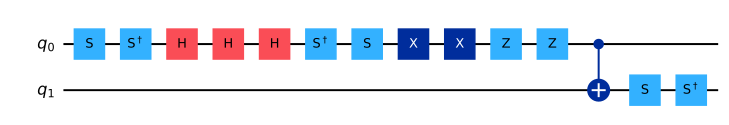

In [52]:
print(metrics.circuit_qubit_count(qc))
print(metrics.circuit_gate_count(qc))
print(metrics.circuit_t_gate_count(qc))


print(metrics.graph_qubit_count(diagram))
print(metrics.graph_gate_count(diagram))
print(metrics.graph_t_gate_count(diagram))
print(metrics.graph_clifford_gate_count(diagram))


integration.pyzx_to_qiskit(diagram)
qc.draw("mpl")


In [53]:
print(loss.naive_loss(qc))
print(loss.informed_loss(qc))

print(loss.naive_loss(qc2))
print(loss.informed_loss(qc2))

6.200000000000001
3.2
1.4
0.8


In [54]:
pyzx.draw(diagram,labels="true")
vertices = (list(diagram.vertices()))
#for i in vertices:
    #print(i)
    #print(rewrite.get_applicable_rules(diagram,i))

new = rewrite.try_fuse(diagram, 6)

print(rewrite.get_applicable_rules(diagram,3))


['color_change', 'fuse_with_2']


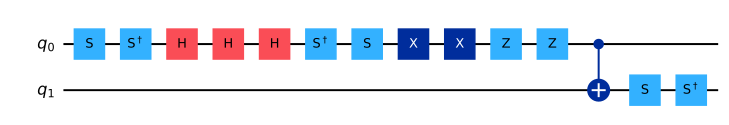

In [55]:
from pyzx import basicrules as br
pyzx.draw(diagram, labels = "true")
pyzx.draw(new,labels="true")
circ = integration.pyzx_to_qiskit(new)
circ.draw("mpl")


True


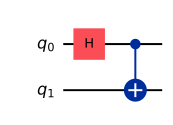

In [56]:
best_diagram, best_cost, history = simulated_annealing.simulated_annealing_zx(
    diagram=diagram,
    cost_function=loss.informed_loss_diagram,
    get_neighbor=simulated_annealing.get_neighbor_random_vertex_random_rule,
    initial_temp=100.0,
    cooling_rate=0.95,
    max_iterations=500
)

pyzx.draw(diagram, labels="true")
pyzx.draw(best_diagram, labels = "true")
print(integration.can_convert_to_circuit(best_diagram))
circ = integration.pyzx_to_qiskit(best_diagram)
circ.draw("mpl")

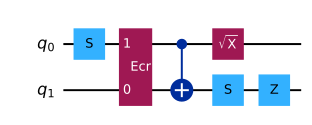

In [57]:
from qiskit.circuit.random import random_clifford_circuit
 
circ = random_clifford_circuit(num_qubits=2, num_gates=6)
circ.draw(output='mpl')

In [58]:
best_diagram, best_cost, history = simulated_annealing.simulated_annealing_zx(
    diagram=new_diagram,
    cost_function=loss.informed_loss_diagram,
    get_neighbor=simulated_annealing.get_neighbor_random_vertex_random_rule,
    initial_temp=100.0,
    cooling_rate=0.95,
    max_iterations=500
)

In [59]:
new_diagram = integration.qiskit_to_pyzx(circ)
pyzx.draw(new_diagram)

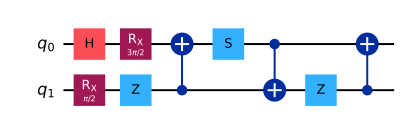

In [60]:
circ2 = integration.pyzx_to_qiskit(best_diagram)
circ2.draw("mpl")

In [65]:
print(loss.informed_loss(circ))
print(loss.informed_loss(circ2))

print(loss.informed_loss_diagram(new_diagram))
print(loss.informed_loss_diagram(best_diagram))


1.6
2.4000000000000004
4.6000000000000005
3.3
